In [1]:
import glob
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib
import kaleido
matplotlib.rcParams['pdf.fonttype'], matplotlib.rcParams['ps.fonttype'] = 42, 42
def findsgrnacolumn(dataframe):
    findsgrnacolumn=list(dataframe.T[0])
    for k in range(len(findsgrnacolumn)):
        if type(findsgrnacolumn[k])==str and len(findsgrnacolumn[k])==20:
            counter=0
            for m in range(len(findsgrnacolumn[k])):
                if findsgrnacolumn[k][m] not in ['A','T','C','G']:
                    counter=1
                if m==19 and counter==0:
                    return(k)
if glob.glob('input/input.csv')!=['input/input.csv']:
    print('Generating input.csv file')
    specificitygroups=input("Enter the column header name of specificity scores in guide specificity file with example in quotation \"SPs1,SPs2,SPs3,SPs5,SPs6,SPs7,SPs8,SPs9\":").split(',')
    funcgroups=input("Enter the column header name of Day6;Day 14;top group;bottom group where groups are seperated by ; and replicates are seperated by , with example in quotation \"D6R1,D6R2,D6R3;D14R1,D14R2,D14R3;AR1,AR2,AR3;UAR1,UAR2,UAR3\". Enter 0 if you have custom scores.:").split(';')
    genecol=input("Enter the column header name of Genes in score file with example in quotation \"Gene\":")
    custom=0
    if funcgroups==['0']:
        funcgroups=input("Enter the column header name of scores where groups are seperated by ; and replicates are seperated by , with example in quotation \"D6R1,D6R2,D6R3;D14R1,D14R2,D14R3;AR1,AR2,AR3;UAR1,UAR2,UAR3\":").split(';')
        custom=1
    csvlist, funccol =glob.glob('input/*.csv'), sum([funcgroups[m].split(',') for m in range(len(funcgroups))],[])
    for k in range(len(csvlist)):
        checkdf=pd.read_csv(csvlist[k])
        if 'input\\guide.csv'==csvlist[k]:
            specificityfile=checkdf.dropna()
        if(all(x in checkdf.columns for x in funccol)):
            functionalfile=checkdf
    specificityfilecol, functionalfilecol=list(specificityfile.columns), list(functionalfile.columns)
    specind=[specificityfilecol[k] for k in range(len(specificityfilecol)) if len(set(specificityfile[specificityfilecol[k]]))==len(specificityfile[specificityfilecol[k]])]
    funcind=[functionalfilecol[m] for m in range(len(functionalfilecol)) if len(set(functionalfile[functionalfilecol[m]]))==len(functionalfile[functionalfilecol[m]])]
    specificitycombine, functionalcombine, maxlen = 0, 0, 0
    for k in range(len(specind)):
        for m in range(len(funcind)):
            intlen=len(set(specificityfile[specind[k]]).intersection(set(functionalfile[funcind[m]])))
            if intlen>maxlen:
                specificitycombine, functionalcombine, maxlen = specind[k], funcind[m], intlen
    controlid=list(set(functionalfile[functionalcombine])-set(specificityfile[specificitycombine]))
    specdf, funcdf=specificityfile.set_index(specificitycombine), functionalfile.set_index(functionalcombine)
    funcgraph=funcdf.reset_index()
    pregfilter=funcgraph[funccol[:3]].values.tolist()
    percentilecut, filteredlist=float(np.percentile((np.mean(pregfilter, axis=1)), 5)), []
    for k in range(len(pregfilter)):
        for m in range(len(pregfilter[k])):
            if percentilecut>pregfilter[k][m]:
                filteredlist.append(funcgraph[functionalcombine][k])
    funcdf=funcgraph[~funcgraph[functionalcombine].isin(filteredlist)]
    controlid=list(set(controlid) & set(funcdf['sgRNA']))
    specificitygroups=list(specdf.columns[1:])
    finalfunc=pd.DataFrame(funcdf[funcgroups[0].split(',')].mean(axis=1),columns=[funcgroups[0]])
    for k in range(1,len(funcgroups)):
        finalfunc=finalfunc.join(pd.DataFrame(funcdf[funcgroups[k].split(',')].mean(axis=1),columns=[funcgroups[k]]))
    if custom==0:
        def controlcorrect(a,b):
            matrix=(finalfunc[funcgroups[a]]/finalfunc[funcgroups[b]])
            return(np.log2(matrix))
        finalfunc=pd.DataFrame(controlcorrect(1,0), columns=['Dropout']).join(pd.DataFrame(controlcorrect(2,3), columns=['Function']))
    graphcol, funcdf =list(finalfunc.columns), funcdf.join(finalfunc)
    def findcategory(df):
        dfcol, colgroup =list(df.columns), []
        for k in range(len(dfcol)):
            dfsubset=df[dfcol[k]]
            if type(dfsubset[1])==str and len(set(dfsubset))<len(dfsubset):
                colgroup.append(dfcol[k]) 
        return(colgroup)
    colgroup=findcategory(funcdf)
    for k in range(len(colgroup)):
        colgrouplist, sgrnaindex, colgrouplistnew=list(funcdf[colgroup[k]]), list(funcdf.index), []
        for m in range(len(colgrouplist)):
            if sgrnaindex[m] in controlid:
                colgrouplistnew.append('Control')
            else:
                colgrouplistnew.append(colgrouplist[m])
        funcdf[colgroup[k]]=colgrouplistnew
    for m in range(len(graphcol)):
        fig = go.Figure()
        for k in range(len(colgroup)):
            genes = set(funcdf[genecol])
            for gene in genes:
                fig.add_trace(go.Violin(x=funcdf[genecol][funcdf[genecol] == gene],y=funcdf[graphcol[m]][funcdf[genecol] == gene],
                                        name=gene,box_visible=True,meanline_visible=True, line_color='black',showlegend=False))
                fig.update_layout(xaxis= {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': colgroup[k]}},
                                 yaxis = {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': graphcol[m]}})
            fig.write_image('output/'+colgroup[k]+' '+graphcol[m]+' violin.pdf')
            fig.write_html('output/'+colgroup[k]+' '+graphcol[m]+' violin interactive.html')
    preinputdf=specdf.join(funcdf.set_index('sgRNA')).reset_index()
    inputdf=preinputdf[specificitygroups+[preinputdf.columns[findsgrnacolumn(preinputdf)]]+list(finalfunc.columns)]
    inputdf.set_index(inputdf.columns[0]).to_csv('input/input.csv')
    print('input.csv file has been generated.')
print('input.csv file has been found in the input folder. Resuming progress from this point. If you would like to start over, delete all files in the output folder.')
inputdf=pd.read_csv('input/input.csv')
sgrnacolumn=findsgrnacolumn(inputdf)
scoreheader, guideheader=list(inputdf.columns)[sgrnacolumn+1:], list(inputdf.columns)[:sgrnacolumn]
if glob.glob('output/annotation.csv')!=['output/annotation.csv']:
    print('Annotation file has not been generated yet in output folder. Generating annotation file. ')
    import mdtraj as md
    import gzip
    import csv
    def analyzepdb(file):
        pdb = md.load(pdbfiles[file])
        dssps, dssp = list(md.compute_dssp(pdb, simplified=False)[0]), list(md.compute_dssp(pdb)[0])
        ssd=pd.DataFrame(zip(dssp,dssps),index=[(k+1) for k in range(len(dssp))], columns=['Secondary Structure','Secondary Structure Detailed'])
        sasa = md.shrake_rupley(pdb, mode = 'residue')[0]
        sasadf=pd.DataFrame(sasa,index=[(k+1) for k in range(len(sasa))],columns=['Solvent-Accessible Surface Area'])
        d = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
         'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
         'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
         'ALA': 'A', 'VAL':'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}
        pdbdf=pdb.topology.to_dataframe()[0].replace({"resName": d}).join(pd.DataFrame(pdb.xyz[0], columns=['X_coord','Y_coord','Z_coord']))
        dfxyz=pdbdf[pdbdf['name'].isin(['N','CA','C','O'])]
        atoms=list(set(dfxyz['name']))
        header=['resSeq']+['resName']+[atoms[k]+'_x' for k in range(len(atoms))]+[atoms[k]+'_y' for k in range(len(atoms))]+[atoms[k]+'_z' for k in range(len(atoms))]
        dfxyzvalues, finalxyz, tempxyz=dfxyz.values.tolist(), [], [0 for k in range(len(header))]
        previd=dfxyzvalues[0][3]
        for k in range(len(dfxyzvalues)):
            if dfxyzvalues[k][3]!=previd:
                finalxyz.append(tempxyz)
                tempxyz=[0 for k in range(len(header))]
            previd, tempxyz[0], tempxyz[1]=dfxyzvalues[k][3], dfxyzvalues[k][3], dfxyzvalues[k][4]
            tempxyz[header.index(dfxyzvalues[k][1]+'_x')], tempxyz[header.index(dfxyzvalues[k][1]+'_y')], tempxyz[header.index(dfxyzvalues[k][1]+'_z')]=dfxyzvalues[k][8], dfxyzvalues[k][9], dfxyzvalues[k][10]
            if k==len(dfxyzvalues)-1:
                finalxyz.append(tempxyz)
        pdbanalyzed=pd.DataFrame(finalxyz, columns=header).sort_values(by=['resSeq']).set_index('resSeq').join(ssd).join(sasadf)
        return(pdbanalyzed)
    pdbfiles, aminolist, pdbdfmatrix=glob.glob('input/*.pdb'), [], []
    for k in range(len(pdbfiles)):
        dfanalyzepdb=analyzepdb(k)
        pdbdfmatrix.append(dfanalyzepdb)
        aminolist.append(list(dfanalyzepdb['resName'])+['*'])
    geneid=[[] for k in range(len(aminolist))]
    def annotation():
        flist, prev, prevAA, aminodone=[], 0, 0, []
        for k in range(1,14):
            with gzip.open('annotation/annotation'+str(k)+'.csv.gz', mode='rt') as file:
                reader = csv.reader(file)
                if k==1:
                    for line in reader:
                        if 'ensembl_peptide_id' in line:
                            columnlabel=line
                            break
                for line in reader:
                    if line[2]!=prev:
                        templist, tempamino=[line], [line[7]]
                    if line[2]==prev:
                        templist.append(line)
                        if line[6]!=prevAA:
                            tempamino.append(line[7])
                    prev, prevAA=line[2], line[6]
                    if tempamino in aminolist:
                        geneid[aminolist.index(tempamino)].append(line[4])
                        flist+=templist
                        print(line[4]+' annotation is complete')
                        if tempamino not in aminodone:
                            aminodone.append(tempamino)
                            if len(aminodone)==len(aminolist):
                                return(pd.DataFrame(flist,columns=columnlabel))
                        templist, tempamino=[], []
            print(str(7.6*k)+'% complete')
    annotation1, masterlistmatrix = annotation(), []
    for k in range(len(geneid)):
        pdbannotation=annotation1[annotation1['transcript_name'].isin([geneid[k][0]])].copy().reset_index()
        pdbannotation['index']=pdbannotation['position'].astype(int)
        masterlistmatrix.append(pdbannotation.set_index('index').join(pdbdfmatrix[k]))
    premlist=pd.concat([masterlistmatrix[k] for k in range(len(masterlistmatrix))]).reset_index()
    premlist['index']=premlist['guide']
    mlist1=premlist.set_index('index')
    mlist2=mlist1.join(inputdf.set_index(list(inputdf.columns)[findsgrnacolumn(inputdf)]))
    listsecstrucdetailed, secstrucnew=list(mlist2['Secondary Structure Detailed']), []
    for k in range(len(listsecstrucdetailed)):
        if listsecstrucdetailed[k]==' ':
            secstrucnew.append('N')
        else:
            secstrucnew.append(listsecstrucdetailed[k])
    mlist2['Secondary Structure Detailed'], mlist2['SecStruct']=secstrucnew, mlist2['Secondary Structure'].replace(['E'], 'B')
    mlist2=mlist2.sort_values(by=['transcript_name','gene_fraction']).reset_index().drop(columns=['index','resName', 'Secondary Structure']).dropna(subset=['Solvent-Accessible Surface Area'])
    MLprep=mlist2.filter(items=['transcript_name','AA', 'offtarget_score', 'doench_score', 'oof_score', 'position', 'provean_score', 'disorder_score']
                     +((list(mlist2.columns)[list(mlist2.columns).index('control')+1:])))
    onehotindex, transcript, AA, secstruc=list(MLprep.index), MLprep['transcript_name'], MLprep['AA'], MLprep['Secondary Structure Detailed']
    transcriptset, AAset, secstrucset=list(set(transcript)), list(set(AA)), list(set(secstruc))
    onehotset=transcriptset+['AA-'+str(AAset[k]) for k in range(len(AAset))]+['SS-'+str(secstrucset[k]) for k in range(len(secstrucset))]
    zeromatrix=[0 for k in range(len(onehotset))]
    tempzero, onehotlist=zeromatrix.copy(), []
    for k in range(len(AA)):
        if list(transcript)[k] in onehotset:
            tempzero[onehotset.index(list(transcript)[k])]=1
        if 'AA-'+list(AA)[k] in onehotset:
            tempzero[onehotset.index('AA-'+list(AA)[k])]=1
        if 'SS-'+list(secstruc)[k] in onehotset:
            tempzero[onehotset.index('SS-'+list(secstruc)[k])]=1
        onehotlist.append([onehotindex[k]]+tempzero)
        tempzero=zeromatrix.copy()
    onehotdf=pd.DataFrame(onehotlist, columns=['numberindex']+onehotset).set_index('numberindex')
    MLfinal=(onehotdf.join(MLprep)).drop(columns=["transcript_name","AA","Secondary Structure Detailed"])
    MLfinal.to_csv('output/train.csv')
    mlist2.to_csv('output/annotation.csv')
    print('Annotation file has been saved. You can resume progress from this point by running the program again.')
print('Generated annotation file has been found in the output folder. Resuming progress from this point. If you would like to start over, delete all files in the output folder.')
from autogluon.tabular import TabularDataset, TabularPredictor
if glob.glob('output/predict.csv')!=['output/predict.csv']:
    import torch
    MLfinal=pd.read_csv('output/train.csv').drop(columns=['numberindex'])
    MLfinal.replace([np.inf, -np.inf, 'NA'], np.nan, inplace=True)
    for k in range(len(scoreheader)):
        if glob.glob('output/Models/'+scoreheader[k])!=['output/Models/'+scoreheader[k]]:
            MLtrain=MLfinal.dropna(subset=[scoreheader[k]]).drop(columns=(scoreheader[:k]+scoreheader[k+1:]))
            predictor=TabularPredictor(label=scoreheader[k], path="output/Models/"+scoreheader[k]).fit(MLtrain, presets="best_quality", time_limit=40000, num_gpus=torch.cuda.device_count(), ag_args_fit={"ag.max_memory_usage_ratio": 2})
    correctlist=guideheader+['offtarget_score', 'doench_score', 'oof_score']
    for k in range(len(correctlist)):
        if type(MLfinal[correctlist[k]].mode()[0])==str:
            MLfinal[correctlist[k]]=[MLfinal[correctlist[k]].mode()[0] for m in range(len(MLfinal))]
        if type(MLfinal[correctlist[k]].mode()[0])!=str:
            MLfinal[correctlist[k]]=[MLfinal[correctlist[k]].median() for m in range(len(MLfinal))]
    mlist2=pd.read_csv('output/annotation.csv').drop(columns=['Unnamed: 0'])
    for k in range(len(scoreheader)):
        predictor = TabularPredictor.load("output/Models/"+scoreheader[k])
        predictdf=pd.DataFrame(predictor.predict(MLfinal))
        predictdf.rename(columns = {scoreheader[k]:scoreheader[k]+' predict'}, inplace = True)
        mlist2=mlist2.join(predictdf)
    mlist2.to_csv('output/predict.csv')
import plotly.express as px
from plotly import subplots
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
mlist2=pd.read_csv('output/predict.csv').drop(columns=['Unnamed: 0'])
mlist2.replace(['#NAME?'], np.nan, inplace=True)
mlist2['Interpro_Description'].replace([np.nan], 'NA', inplace=True)
mlist2['Secondary Structure Detailed'].replace(['N'], 'Loops and irregular elements', inplace=True)
mlist2['Secondary Structure Detailed'].replace(['H'], 'Alpha helix', inplace=True)
mlist2['Secondary Structure Detailed'].replace(['B'], 'Residue in isolated beta-bridge', inplace=True)
mlist2['Secondary Structure Detailed'].replace(['E'], 'Extended strand, participates in beta ladder', inplace=True)
mlist2['Secondary Structure Detailed'].replace(['G'], '3-helix (3/10 helix)', inplace=True)
mlist2['Secondary Structure Detailed'].replace(['I'], '5 helix (pi helix)', inplace=True)
mlist2['Secondary Structure Detailed'].replace(['T'], 'hydrogen bonded turn', inplace=True)
mlist2['Secondary Structure Detailed'].replace(['S'], 'bend', inplace=True)
for k in range(len(scoreheader)):
    mlist2[scoreheader[k]]=mlist2[scoreheader[k]].astype(float)
transcriptset, predictcol=list(set(mlist2['transcript_name'])), [scoreheader[m]+' predict' for m in range(len(scoreheader))]
parallelcollist=['position','provean_score','disorder_score','Solvent-Accessible Surface Area']+predictcol
for k in range(len(transcriptset)):
    plotdf=mlist2[mlist2['transcript_name'].isin([transcriptset[k]])]
    fig = go.Figure(data=go.Parcoords(line = dict(color = plotdf['position'],colorscale = px.colors.diverging.Tealrose),
        dimensions = [dict(label = parallelcollist[k], values = plotdf[parallelcollist[k]]) for k in range(len(parallelcollist))]),
                   layout = go.Layout(autosize=False,width=800,height=500, title=transcriptset[k]))
    fig.write_image('output/'+transcriptset[k]+'_parallelplot.pdf')
    fig.write_html('output/'+transcriptset[k]+' parallelplot interactive.html')
    def pca(columns, whichpca):
        X = plotdf[columns]
        pca = PCA(n_components=2)
        components = pca.fit_transform(X)
        loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
        fig = px.scatter(components, x=0, y=1, color=plotdf[predictcol[m]], size=plotdf['Solvent-Accessible Surface Area'])
        for i, feature in enumerate(columns):
            fig.add_annotation(ax=0, ay=0,axref="x", ayref="y",x=loadings[i, 0],y=loadings[i, 1],showarrow=True,arrowsize=2,arrowhead=2,xanchor="right",yanchor="top")
            fig.add_annotation(x=loadings[i, 0],y=loadings[i, 1],ax=0, ay=0,xanchor="center", yanchor="bottom",text=feature,yshift=5)
        fig.update_layout(title={'text': transcriptset[k],'y':0.95,'x':0.5,'xanchor': 'center','yanchor': 'top'},
                          xaxis= {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': whichpca+'PC1 ('+str(round(pca.explained_variance_ratio_[0], 3)*100)+'% Variance)'}},
                         yaxis = {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': whichpca+'PC2 ('+str(round(pca.explained_variance_ratio_[1], 3)*100)+'% Variance)'}},
                         coloraxis = {'colorbar': {'title': {'text': scoreheader[m]}}})
        fig.write_image('output/'+transcriptset[k]+' '+scoreheader[m]+' '+whichpca+'PCA.pdf')
        fig.write_html('output/'+transcriptset[k]+' '+scoreheader[m]+' '+whichpca+'PCA interactive.html')
    for m in range(len(predictcol)):
        pca(['CA_x','CA_y','CA_z'], '3D ')
        pca(['provean_score','disorder_score','Solvent-Accessible Surface Area'], 'PDS ')
        violingroup=['AA','Interpro_Description','Secondary Structure Detailed']
        for n in range(len(violingroup)):
            fig = go.Figure()
            groups = set(plotdf[violingroup[n]])
            if n==0:
                for group in groups:
                    fig.add_trace(go.Violin(x=plotdf[violingroup[n]][plotdf[violingroup[n]] == group],y=plotdf[predictcol[m]][plotdf[violingroup[n]] == group],
                                    name=group,box_visible=True,meanline_visible=True, line_color='black',showlegend=False))
            else:
                for group in groups:
                    fig.add_trace(go.Violin(x=plotdf[violingroup[n]][plotdf[violingroup[n]] == group],y=plotdf[predictcol[m]][plotdf[violingroup[n]] == group],
                                    name=group,box_visible=True,meanline_visible=True))
            fig.update_layout(title={'text': transcriptset[k],'y':0.95,'x':0.5,'xanchor': 'center','yanchor': 'top'},
                                  xaxis= {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': violingroup[n]}},
                                 yaxis = {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': scoreheader[m]}})
            fig.write_image('output/'+transcriptset[k]+' '+scoreheader[m]+' '+violingroup[n]+' violin.pdf')
            fig.write_html('output/'+transcriptset[k]+' '+scoreheader[m]+' '+violingroup[n]+' violin interactive.html')
        fig2 = px.scatter(plotdf, x="position", y=predictcol[m], color="Interpro_Description", marginal_y="box", size="Solvent-Accessible Surface Area")
        fig2.update_yaxes(title_text=scoreheader[m], col=1)
        fig2.update_xaxes(title_text='Position', col=1)
        fig2.update_layout(title_text=transcriptset[k])
        fig2.write_image('output/'+transcriptset[k]+' '+scoreheader[m]+' SASAsize.pdf')
        fig2.write_html('output/'+transcriptset[k]+' '+scoreheader[m]+' SASAsize interactive.html')
    position, exon, lineargroups=list(plotdf['position']), list(plotdf['Exon']), scoreheader+['provean_score','disorder_score']
    fig=subplots.make_subplots(rows=(len(lineargroups)),cols=1, vertical_spacing = 0.01)
    for t in range(len(lineargroups)):
        if lineargroups[t] in scoreheader:
            fig.add_trace(go.Scatter(x=position, y=plotdf[lineargroups[t]], name = lineargroups[t]+' raw', mode='markers', legendgroup = str(t+1)), row=t+1, col=1)
            predict=list(plotdf[lineargroups[t]+' predict'])
            fig.add_trace(go.Scatter(x=position, y=predict, name = lineargroups[t]+' guide efficiency corrected', legendgroup = str(t+1)), row=t+1, col=1)
        if lineargroups[t] == 'provean_score':
            setdomain=list(set(plotdf["Interpro_Description"]))
            for m in range(len(setdomain)):
                domainsubset=plotdf[plotdf['Interpro_Description'].isin([setdomain[m]])]
                fig.add_trace(go.Scatter(x=domainsubset["position"], y=domainsubset[lineargroups[t]], name = setdomain[m], mode='markers', legendgroup = str(t+1)), row=t+1, col=1)
        if lineargroups[t] == 'disorder_score':
            setss=list(set(plotdf["Secondary Structure Detailed"]))
            for m in range(len(setss)):
                ssubset=plotdf[plotdf["Secondary Structure Detailed"].isin([setss[m]])]
                fig.add_trace(go.Scatter(x=ssubset["position"], y=ssubset[lineargroups[t]], name = setss[m], mode='markers', legendgroup = str(t+1)), row=t+1, col=1)
        fig.update_yaxes(title_text=lineargroups[t], row=t+1, col=1)
    #fig.update_layout(height=275*len(lineargroups), width=1100, legend_tracegroupgap = 180, title_text=transcriptset[k], colorway=px.colors.qualitative.Dark24)
    fig.update_layout(height=275*len(lineargroups), width=1100, legend_tracegroupgap = 200, title_text=transcriptset[k])
    fig.update_xaxes(range=[0,max(list(position))+1],showgrid=False,showticklabels=False)
    fig.update_xaxes(title_text='Position', showticklabels=True, row=len(lineargroups), col=1)
    eold=exon[0]
    for e in range(len(exon)):
        if exon[e]!=eold:
            fig.add_vline(x=(position[e]+position[e-1])/2, line_dash="dot", row='all', col=1, line_color="#000000", line_width=2)
            eold=exon[e]
    fig.write_image('output/'+transcriptset[k]+' linear tracks.pdf')
    fig.write_html('output/'+transcriptset[k]+' linear tracks interactive.html')

input.csv file has been found in the input folder. Resuming progress from this point. If you would like to start over, delete all files in the output folder.
Generated annotation file has been found in the output folder. Resuming progress from this point. If you would like to start over, delete all files in the output folder.


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.1
Python Version:     3.11.14
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22631
CPU Count:          16
Memory Avail:       8.49 GB / 15.93 GB (53.3%)
Disk Space Avail:   42.21 GB / 459.00 GB (9.2%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdout validation data is used to detect stacked overfitting.
	Running DyStack for up t

(_ray_fit pid=3156) [1000]	valid_set's rmse: 0.150402
(_ray_fit pid=3156) [9000]	valid_set's rmse: 0.135332 [repeated 40x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)


(_dystack pid=10292) 	-0.1852	 = Validation score   (-root_mean_squared_error)
(_dystack pid=10292) 	8.22s	 = Training   runtime
(_dystack pid=10292) 	0.27s	 = Validation runtime
(_dystack pid=10292) Fitting model: LightGBM_BAG_L1 ... Training model for up to 6647.67s of the 9980.81s of remaining time.
(_dystack pid=10292) Specified total num_gpus: 1, but only 0 are available. Will use 0 instead
(_dystack pid=10292) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=2, gpus=0, memory=0.20%)


(_ray_fit pid=11864) [1000]	valid_set's rmse: 0.139646 [repeated 8x across cluster]
(_ray_fit pid=6804) [5000]	valid_set's rmse: 0.286191 [repeated 24x across cluster]
(_ray_fit pid=6804) [10000]	valid_set's rmse: 0.286159 [repeated 8x across cluster]


...

(_dystack pid=10292) 	-0.1501	 = Validation score   (-root_mean_squared_error)
(_dystack pid=10292) 	6.23s	 = Training   runtime
(_dystack pid=10292) 	0.08s	 = Validation runtime
(_dystack pid=10292) Fitting model: XGBoost_r22_BAG_L2 ... Training model for up to 2609.72s of the 2609.48s of remaining time.
(_dystack pid=10292) Specified total num_gpus: 1, but only 0 are available. Will use 0 instead
(_dystack pid=10292) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=2, gpus=0, memory=0.74%)
(_ray_fit pid=1776) C:\Users\jngos\anaconda3\envs\myenv\Lib\site-packages\autogluon\common\utils\try_import.py:107: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
(_ray_fit pid=1776)   from pkg_resources import parse_version  # pylint: disable=impor

(_ray_fit pid=5076) [1000]	valid_set's rmse: 0.181706 [repeated 20x across cluster]


(_dystack pid=10292) 	-0.1255	 = Validation score   (-root_mean_squared_error)
(_dystack pid=10292) 	5.02s	 = Training   runtime
(_dystack pid=10292) 	0.04s	 = Validation runtime
(_dystack pid=10292) Fitting model: NeuralNetFastAI_r172_BAG_L2 ... Training model for up to 2557.66s of the 2557.42s of remaining time.
(_dystack pid=10292) Specified total num_gpus: 1, but only 0 are available. Will use 0 instead
(_dystack pid=10292) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=2, gpus=0, memory=0.07%)
(_ray_fit pid=9548) C:\Users\jngos\anaconda3\envs\myenv\Lib\site-packages\autogluon\common\utils\try_import.py:131: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
(_ray_fit pid=9548)   from pkg_resources import parse_version  # pylint: disa

(_ray_fit pid=15908) [1000]	valid_set's rmse: 0.211325 [repeated 3x across cluster]


(_dystack pid=10292) 	-0.1475	 = Validation score   (-root_mean_squared_error)
(_dystack pid=10292) 	6.14s	 = Training   runtime
(_dystack pid=10292) 	0.09s	 = Validation runtime
(_dystack pid=10292) Fitting model: NeuralNetTorch_r1_BAG_L2 ... Training model for up to 2010.77s of the 2010.54s of remaining time.
(_dystack pid=10292) Specified total num_gpus: 1, but only 0 are available. Will use 0 instead
(_dystack pid=10292) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=2, gpus=0, memory=0.03%)
(_dystack pid=10292) 	-0.1461	 = Validation score   (-root_mean_squared_error)
(_dystack pid=10292) 	18.84s	 = Training   runtime
(_dystack pid=10292) 	0.1s	 = Validation runtime
(_dystack pid=10292) Fitting model: NeuralNetTorch_r89_BAG_L2 ... Training model for up to 1989.29s of the 1989.05s of remaining time.
(_dystack pid=10292) Specified total num_gpus: 1, but only 0 are available. Will use 0 instead
(_dystack pid=10292) 	Fitting

In [108]:
import glob
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib
import kaleido
matplotlib.rcParams['pdf.fonttype'], matplotlib.rcParams['ps.fonttype'] = 42, 42
def findsgrnacolumn(dataframe):
    findsgrnacolumn=list(dataframe.T[0])
    for k in range(len(findsgrnacolumn)):
        if type(findsgrnacolumn[k])==str and len(findsgrnacolumn[k])==20:
            counter=0
            for m in range(len(findsgrnacolumn[k])):
                if findsgrnacolumn[k][m] not in ['A','T','C','G']:
                    counter=1
                if m==19 and counter==0:
                    return(k)
if glob.glob('input/input.csv')==['input/input.csv']:
    print('Generating input.csv file')
    #specificitygroups=input("Enter the column header name of specificity scores in guide specificity file with example in quotation \"SPs1,SPs2,SPs3,SPs5,SPs6,SPs7,SPs8,SPs9\":").split(',')
    #funcgroups=input("Enter the column header name of Day6;Day 14;top group;bottom group where groups are seperated by ; and replicates are seperated by , with example in quotation \"D6R1,D6R2,D6R3;D14R1,D14R2,D14R3;AR1,AR2,AR3;UAR1,UAR2,UAR3\". Enter 0 if you have custom scores.:").split(';')
    #genecol=input("Enter the column header name of Genes in score file with example in quotation \"Gene\":")
    custom=0
    if funcgroups==['0']:
        funcgroups=input("Enter the column header name of scores where groups are seperated by ; and replicates are seperated by , with example in quotation \"D6R1,D6R2,D6R3;D14R1,D14R2,D14R3;AR1,AR2,AR3;UAR1,UAR2,UAR3\":").split(';')
        custom=1
    csvlist, funccol =glob.glob('input/*.csv'), sum([funcgroups[m].split(',') for m in range(len(funcgroups))],[])
    for k in range(len(csvlist)):
        checkdf=pd.read_csv(csvlist[k])
        if 'input/guide.csv'==csvlist[k]:
            specificityfile=checkdf.dropna()
        if(all(x in checkdf.columns for x in funccol)):
            functionalfile=checkdf
    specificityfilecol, functionalfilecol=list(specificityfile.columns), list(functionalfile.columns)
    specind=[specificityfilecol[k] for k in range(len(specificityfilecol)) if len(set(specificityfile[specificityfilecol[k]]))==len(specificityfile[specificityfilecol[k]])]
    funcind=[functionalfilecol[m] for m in range(len(functionalfilecol)) if len(set(functionalfile[functionalfilecol[m]]))==len(functionalfile[functionalfilecol[m]])]
    specificitycombine, functionalcombine, maxlen = 0, 0, 0
    for k in range(len(specind)):
        for m in range(len(funcind)):
            intlen=len(set(specificityfile[specind[k]]).intersection(set(functionalfile[funcind[m]])))
            if intlen>maxlen:
                specificitycombine, functionalcombine, maxlen = specind[k], funcind[m], intlen
    controlid=list(set(functionalfile[functionalcombine])-set(specificityfile[specificitycombine]))
    specdf, funcdf=specificityfile.set_index(specificitycombine), functionalfile.set_index(functionalcombine)
    funcgraph=funcdf.reset_index()
    pregfilter=funcgraph[funccol[:3]].values.tolist()
    percentilecut, filteredlist=float(np.percentile((np.mean(pregfilter, axis=1)), 5)), []
    for k in range(len(pregfilter)):
        for m in range(len(pregfilter[k])):
            if percentilecut>pregfilter[k][m]:
                filteredlist.append(funcgraph[functionalcombine][k])
    funcdf=funcgraph[~funcgraph[functionalcombine].isin(filteredlist)]
    controlid=list(set(controlid) & set(funcdf['sgRNA']))
    specificitygroups=list(specdf.columns[1:])
    finalfunc=pd.DataFrame(funcdf[funcgroups[0].split(',')].mean(axis=1),columns=[funcgroups[0]])
    for k in range(1,len(funcgroups)):
        finalfunc=finalfunc.join(pd.DataFrame(funcdf[funcgroups[k].split(',')].mean(axis=1),columns=[funcgroups[k]]))
    if custom==0:
        def controlcorrect(a,b):
            matrix=(finalfunc[funcgroups[a]]/finalfunc[funcgroups[b]])
            return(np.log2(matrix))
        finalfunc=pd.DataFrame(controlcorrect(1,0), columns=['Dropout']).join(pd.DataFrame(controlcorrect(2,3), columns=['Function']))
    graphcol, funcdf =list(finalfunc.columns), funcdf.join(finalfunc)
    def findcategory(df):
        dfcol, colgroup =list(df.columns), []
        for k in range(len(dfcol)):
            dfsubset=df[dfcol[k]]
            if type(dfsubset[1])==str and len(set(dfsubset))<len(dfsubset):
                colgroup.append(dfcol[k]) 
        return(colgroup)
    colgroup=findcategory(funcdf)
    for k in range(len(colgroup)):
        colgrouplist, sgrnaindex, colgrouplistnew=list(funcdf[colgroup[k]]), list(funcdf.index), []
        for m in range(len(colgrouplist)):
            if sgrnaindex[m] in controlid:
                colgrouplistnew.append('Control')
            else:
                colgrouplistnew.append(colgrouplist[m])
        funcdf[colgroup[k]]=colgrouplistnew
    funcdf=funcc.copy()
    for m in range(len(graphcol)):
        fig = go.Figure()
        for k in range(len(colgroup)):
            genes = set(funcdf[genecol])
            for gene in genes:
                
                fig.add_trace(go.Violin(x=funcdf[genecol][funcdf[genecol] == gene],y=funcdf[graphcol[m]][funcdf[genecol] == gene], color='Gene',
                                        name=gene,box_visible=True,meanline_visible=True, line_color='black',showlegend=False, points='all'))
                fig.update_layout(xaxis= {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': colgroup[k]}},
                                 yaxis = {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': graphcol[m]}})
                fig.update_layout(
                    plot_bgcolor="white",
                    paper_bgcolor="white", width=1100, height=300, xaxis={'categoryorder': 'array', 'categoryarray': ordered_classes})
                fig.update_xaxes(
                    showline=True,       
                    linewidth=1,          
                    linecolor='black',
                    ticks="outside",      
                    tickwidth=0,
                    tickcolor='black',
                    ticklen=5,          
                    showgrid=False         
                    )
                fig.update_yaxes(
                    showline=True,
                    linewidth=1,
                    linecolor='black',
                    ticks="outside",showgrid=False, range=[-0.3,0.85]
                    )
                annotate(fig, 2, 8, 0.85, 'p=0.03', 210)
                fig.update_traces(marker_size=1)
            fig.write_image('output/'+colgroup[k]+' '+graphcol[m]+' violin.pdf')
            fig.write_html('output/'+colgroup[k]+' '+graphcol[m]+' violin interactive.html')

Generating input.csv file


ValueError: Invalid property specified for object of type plotly.graph_objs.Violin: 'color'

Did you mean "box"?

    Valid properties:
        alignmentgroup
            Set several traces linked to the same position axis or
            matching axes to the same alignmentgroup. This controls
            whether bars compute their positional range dependently
            or independently.
        bandwidth
            Sets the bandwidth used to compute the kernel density
            estimate. By default, the bandwidth is determined by
            Silverman's rule of thumb.
        box
            :class:`plotly.graph_objects.violin.Box` instance or
            dict with compatible properties
        customdata
            Assigns extra data each datum. This may be useful when
            listening to hover, click and selection events. Note
            that, "scatter" traces also appends customdata items in
            the markers DOM elements
        customdatasrc
            Sets the 

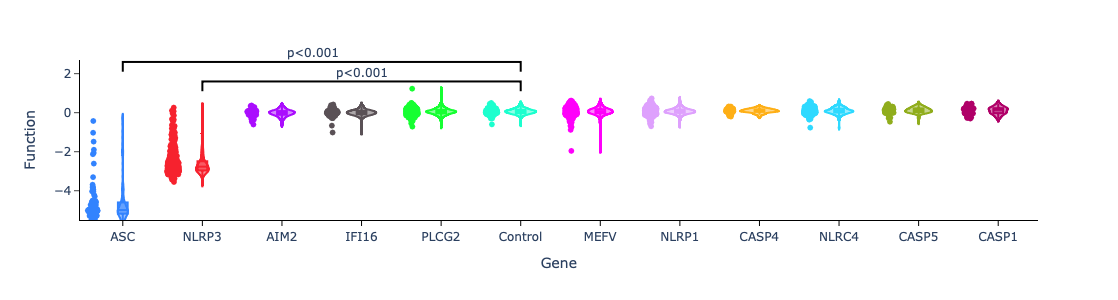

In [249]:
import plotly.express as px
fig=px.violin(check, x='Gene', y='Function', color='Gene', points='all',box=True,color_discrete_map=color_map)
fig.update_layout(plot_bgcolor="white",paper_bgcolor="white", width=1100, height=300, xaxis={'categoryorder': 'array', 'categoryarray': ordered_classes})
fig.update_xaxes(
                    showline=True,       
                    linewidth=1,          
                    linecolor='black',
                    ticks="outside",      
                    tickwidth=0,
                    tickcolor='black',
                    ticklen=5,          
                    showgrid=False         
                    )
fig.update_yaxes(
                    showline=True,
                    linewidth=1,
                    linecolor='black',
                    ticks="outside",showgrid=False, range=[-5.5,2.7]
                    )
annotate(fig, 1, 5, 1.6, 'p<0.001', 160)
annotate(fig, 0, 5, 2.6, 'p<0.001', 190)
fig.update_layout(showlegend=False)
fig.write_image('function violin.pdf')
fig.show()

In [135]:
color_map={'IFI16':'#5A5156','AIM2':'#E4E1E3','NLRP3':'#F6222E','MEFV':'#FE00FA',
           'PLCG2':'#16FF32','ASC':'#3283FE','CASP4':'#FEAF16','CASP1':'#B00068','Neutral Region':'#1CFFCE',
           'NLRC4':'#2ED9FF','CASP5':'#90AD1C','NLRP1':'#DEA0FD','nontargeting':'#AA0DFE'}

In [174]:
color_map={'IFI16':'#5A5156','AIM2':'#AA0DFE','NLRP3':'#F6222E','MEFV':'#FE00FA',
           'PLCG2':'#16FF32','ASC':'#3283FE','CASP4':'#FEAF16','CASP1':'#B00068','Control':'#1CFFCE',
           'NLRC4':'#2ED9FF','CASP5':'#90AD1C','NLRP1':'#DEA0FD'}

In [ ]:
fig = px.pie(final, values='count', names='Gene', hover_data=['count'], labels={'count':'sgRNA count'},width=500, height=480, hole=.5)
fig.update_layout(title_text='sgRNA counts', title_x=0.5, showlegend=False)
fig.update_traces(textposition='auto',textinfo='value+label+percent')
fig.show()

In [133]:
color_map

NameError: name 'color_map' is not defined

In [247]:
funcdf.loc[funcdf['Gene'] == 'neurtal region', 'Gene'] = 'Neutral Region'
funcdf.loc[funcdf['Gene'] == 'AAVS', 'Gene'] = 'Neutral Region'
def annotate(fig, x1, x2, y, text, xshift):
    fig.add_shape(type='path',path=f"M {x1},{y-0.5} L {x1},{y} L {x2}, {y} L {x2},{y-0.5}", line_color='black')
    fig.add_annotation(x=(x1+x1)/2, y=y, text=text, showarrow=False, yshift=10, xshift=xshift)

In [56]:
funcc=funcdf.copy()

In [177]:
check=funcc.copy()
check
check.loc[check['Gene'] == 'Neutral Region', 'Gene'] = 'Control'
check.loc[check['Gene'] == 'nontargeting', 'Gene'] = 'Control'

In [9]:
import pandas as pd
from scipy import stats
import numpy as np
# 1. Group the data by Column A and extract Column B values
# This creates a list of arrays: [group1_values, group2_values, ...]


In [15]:
nurd=pd.read_csv('Nurd.csv')
nurd
check=nurd.copy()
check
check['gene_name'] = check['gene_name'].fillna('Control')
check=check.dropna(subset=['highHbF-presort'])

In [16]:
groups = [data['highHbF-presort'].values for name, data in check.groupby('gene_name')]
h_stat, p_value = stats.kruskal(*groups)
#Dropout
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Significant difference detected between groups.")

Kruskal-Wallis H-statistic: 4859.3098
P-value: 0.0000e+00
Significant difference detected between groups.


In [14]:
groups

[array([ 0.46791503, -0.45426301, -0.45426301, ...,         nan,
        -1.17451465, -1.17451465]),
 array([ 0.22495548,  1.50110954,  0.22495548, ..., -0.03062635,
                nan,         nan]),
 array([-1.11360962e-01,  1.16574004e-01,  9.38954643e-01,  9.51093099e-02,
        -1.33085960e+00,  1.64232186e+00,  9.34334828e-02,  2.72529347e-01,
         1.40250891e-01, -3.61790553e-01,  2.19812699e-01, -8.35657666e-01,
         3.14338433e-01, -1.62089900e-01, -4.96828574e-01,  5.88328131e-01,
        -5.52487411e-01, -6.11790204e-01,  7.48244218e-02, -5.95722044e-01,
         7.05877259e-01,  2.19544533e-01, -1.07760072e+00, -7.10132856e-01,
         5.31428531e-01, -4.61215393e-01,  1.91760521e-02,  2.52014293e-01,
        -4.75834284e-01,  1.02072094e+00,  1.91622734e-01, -2.33703424e-01,
         4.66788570e-02, -5.34033128e-01,  1.17023904e+00, -1.93495311e-01,
        -9.57953447e-02,  7.18411078e-01,  5.50079981e-01, -3.72417321e-01,
         6.62884859e-01,  2.88634864e-

In [250]:
groups = [data['Dropout'].values for name, data in check.groupby('Gene')]
h_stat, p_value = stats.kruskal(*groups)
#Dropout
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Significant difference detected between groups.")

Kruskal-Wallis H-statistic: 256.0303
P-value: 1.5239e-48
Significant difference detected between groups.


In [262]:
groups = [data['Function'].values for name, data in check.groupby('Gene')]
h_stat, p_value = stats.kruskal(*groups)
#Dropout
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Significant difference detected between groups.")

Kruskal-Wallis H-statistic: 1226.3686
P-value: 3.3569e-256
Significant difference detected between groups.


In [17]:
#nurd
import scikit_posthocs as sp

posthoc_results = sp.posthoc_dunn(check, val_col='highHbF-presort', group_col='gene_name', p_adjust='bonferroni')

print(posthoc_results)

                  CHD3           CHD4        Control        GATAD2A  \
CHD3      1.000000e+00   0.000000e+00   1.116753e-02  4.562572e-156   
CHD4      0.000000e+00   1.000000e+00  4.689528e-111   6.753171e-35   
Control   1.116753e-02  4.689528e-111   1.000000e+00   6.062916e-36   
GATAD2A  4.562572e-156   6.753171e-35   6.062916e-36   1.000000e+00   
HDAC1     1.000000e+00   1.185825e-92   1.000000e+00   4.606640e-37   
HDAC2     9.251694e-41   3.743784e-23   8.065251e-14   1.000000e+00   
MBD2     1.701171e-108   4.435863e-18   2.821519e-33   1.000000e+00   
MBD3      1.000000e+00  2.945911e-205   7.593297e-04   1.515565e-81   
MTA1      8.743412e-02   0.000000e+00   3.154347e-06  2.394871e-140   
MTA2     2.549767e-166   7.503194e-11   1.637460e-48   3.423031e-02   
MTA3      1.000000e+00  1.283283e-140   1.000000e+00   7.315872e-50   
RBBP4     1.595902e-03  8.491503e-110   1.000000e+00   1.272596e-34   
RBBP7     1.000000e+00  2.070318e-127   1.000000e+00   4.905135e-46   
ZBTB7A

In [18]:
significant_pairs = posthoc_results[posthoc_results < 0.05]
print(significant_pairs)

                  CHD3           CHD4        Control        GATAD2A  \
CHD3               NaN   0.000000e+00   1.116753e-02  4.562572e-156   
CHD4      0.000000e+00            NaN  4.689528e-111   6.753171e-35   
Control   1.116753e-02  4.689528e-111            NaN   6.062916e-36   
GATAD2A  4.562572e-156   6.753171e-35   6.062916e-36            NaN   
HDAC1              NaN   1.185825e-92            NaN   4.606640e-37   
HDAC2     9.251694e-41   3.743784e-23   8.065251e-14            NaN   
MBD2     1.701171e-108   4.435863e-18   2.821519e-33            NaN   
MBD3               NaN  2.945911e-205   7.593297e-04   1.515565e-81   
MTA1               NaN   0.000000e+00   3.154347e-06  2.394871e-140   
MTA2     2.549767e-166   7.503194e-11   1.637460e-48   3.423031e-02   
MTA3               NaN  1.283283e-140            NaN   7.315872e-50   
RBBP4     1.595902e-03  8.491503e-110            NaN   1.272596e-34   
RBBP7              NaN  2.070318e-127            NaN   4.905135e-46   
ZBTB7A

In [287]:
check[check['Gene'] == 'Control']['Function']

353     0.086704
413     0.450159
415     0.237004
418     0.339816
488     0.026207
          ...   
2851    0.387945
2871   -0.061082
2881    0.168939
2883   -0.077025
2894    0.027273
Name: Function, Length: 215, dtype: float64

In [264]:
np.median(check[check['Gene'] == 'Control']['Function'])

0.0633897011704307

In [265]:
np.median(check[check['Gene'] == 'ASC']['Function'])

-4.988539225091438

In [268]:
0.0633897011704307--2.766405882061812

2.8297955832322423

In [278]:
1-(1/(2**5.051928926261869))

0.969854821679344

In [276]:
1-(1/(2**2.8297955832322423))

0.8593477616826108

In [ ]:
1/

In [251]:
import scikit_posthocs as sp

posthoc_results = sp.posthoc_dunn(check, val_col='Dropout', group_col='Gene', p_adjust='bonferroni')

print(posthoc_results)

                 AIM2       ASC     CASP1     CASP4     CASP5       Control  \
AIM2     1.000000e+00  0.504746  0.479178  0.807758  0.458267  1.206614e-11   
ASC      5.047464e-01  1.000000  1.000000  1.000000  1.000000  7.971311e-05   
CASP1    4.791777e-01  1.000000  1.000000  1.000000  1.000000  1.056063e-03   
CASP4    8.077575e-01  1.000000  1.000000  1.000000  1.000000  5.467513e-05   
CASP5    4.582670e-01  1.000000  1.000000  1.000000  1.000000  2.481978e-04   
Control  1.206614e-11  0.000080  0.001056  0.000055  0.000248  1.000000e+00   
IFI16    1.000000e+00  0.341677  0.360814  0.633444  0.316525  4.448611e-18   
MEFV     1.000000e+00  0.329222  0.381849  0.678718  0.312287  9.177028e-26   
NLRC4    1.999851e-03  1.000000  1.000000  1.000000  1.000000  1.619533e-05   
NLRP1    1.471040e-05  1.000000  1.000000  1.000000  1.000000  3.947015e-04   
NLRP3    1.000000e+00  0.058734  0.081338  0.141319  0.058568  2.884567e-29   
PLCG2    1.000000e+00  1.000000  1.000000  1.000000 

In [252]:
check

,sgRNA,Gene,D6R1,D6R2,D6R3,D14R1,D14R2,D14R3,AR1,AR2,AR3,UAR1,UAR2,UAR3,ARday14 pval,URday14 pval,day14day6 pval,Dropout,Function
0,>ASC_sgRNA69,ASC,2778.728545,3060.725166,3243.259371,2901.438602,2905.150795,2944.173306,310.420940,336.901488,297.191814,8612.336721,9359.211287,6060.799918,1.370000e-08,0.006979,0.460943,-0.053715,-4.669261
1,>ASC_sgRNA33,ASC,2740.866722,2131.359645,2055.069727,2317.067943,2261.166076,2279.212045,178.992720,229.093012,207.068664,8512.493756,8486.053604,4446.439063,7.420000e-08,0.022778,0.919951,-0.014621,-5.123548
2,>ASC_sgRNA82,ASC,2879.144683,2824.520628,2883.917249,2437.854891,2438.285939,2493.834025,161.468957,242.569072,229.599452,9890.326676,9663.391939,6174.671474,2.260000e-07,0.007040,0.000108,-0.220592,-5.343560
3,>ASC_sgRNA27,ASC,2930.998919,2982.358240,2832.770013,2808.721860,2824.291727,2757.066965,234.067403,318.035005,227.453662,8907.167124,10600.234830,5998.688161,2.310000e-07,0.013206,0.070125,-0.059960,-5.032045
4,>ASC_sgRNA25,ASC,3693.173869,3889.648571,3618.339105,3519.833755,3633.845014,3675.172099,524.461186,512.090262,511.770740,10826.501300,12235.101080,7197.880953,3.090000e-07,0.012501,0.254189,-0.048768,-4.288610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2900,>PLCG2_sgRNA118,PLCG2,370.387395,458.060203,537.701715,458.480037,555.424787,454.925221,508.189120,541.737593,418.428907,452.229901,393.842717,355.780506,9.975983e-01,0.108750,0.589720,0.104552,0.288941
2901,>MEFV_sgRNA384,MEFV,3265.170657,3469.116191,3130.473158,3020.524326,3136.176703,3025.803033,2932.726868,3270.639647,2978.355504,3093.957300,2932.033333,2789.580689,9.982601e-01,0.270218,0.097164,-0.103396,0.058711
2902,>NLRC4_sgRNA193,NLRC4,3977.137538,4686.562949,4653.087040,4452.104851,4791.862378,4581.353789,4584.967357,4709.882804,4529.761145,4344.930924,4283.668019,4344.553987,9.984220e-01,0.048309,0.537123,0.054067,0.091710
2903,>NLRP1_sgRNA421,NLRP1,2578.719352,2620.325115,2498.345775,2636.898173,2888.786460,2718.545071,2678.632308,2720.816418,2845.316569,2506.645740,2599.361931,2711.123732,9.985038e-01,0.207829,0.091363,0.099015,0.076839


In [143]:
funcdf['Gene']==

0         ASC
1         ASC
2         ASC
3         ASC
4         ASC
        ...  
2900    PLCG2
2901     MEFV
2902    NLRC4
2903    NLRP1
2904    IFI16
Name: Gene, Length: 2807, dtype: object

In [59]:
significant_pairs = posthoc_results[posthoc_results < 0.05]
print(significant_pairs)

                        AIM2           ASC         CASP1         CASP4  \
AIM2                     NaN           NaN           NaN           NaN   
ASC                      NaN           NaN           NaN           NaN   
CASP1                    NaN           NaN           NaN           NaN   
CASP4                    NaN           NaN           NaN           NaN   
CASP5                    NaN           NaN           NaN           NaN   
IFI16                    NaN           NaN           NaN           NaN   
MEFV                     NaN           NaN           NaN           NaN   
NLRC4           5.307388e-04           NaN           NaN           NaN   
NLRP1           4.520399e-06           NaN           NaN           NaN   
NLRP3                    NaN  1.428845e-02  1.899583e-02  3.055923e-02   
Neutral Region           NaN           NaN           NaN           NaN   
PLCG2                    NaN           NaN           NaN           NaN   
nontargeting    4.194289e-21  1.999432

In [198]:
# 1. Group by Class (Column A), get the Median of Score (Column B)
# 2. Sort those medians in ascending order
# 3. Extract the index (the class names) as a list
ordered_classes = check.groupby('Gene')['Function'].median().sort_values().index.tolist()

ordered_classes

['ASC',
 'NLRP3',
 'AIM2',
 'IFI16',
 'PLCG2',
 'Control',
 'MEFV',
 'NLRP1',
 'CASP4',
 'NLRC4',
 'CASP5',
 'CASP1']

In [60]:
import pandas as pd
seqf=[]
strandf=[]
for k in range(5):
    temp=pd.read_csv('result'+str(k+1)+'.txt', sep='\t')
    seqf+=list(temp['DNA'])
    strandf+=list(temp['Direction'])

In [17]:
df=pd.read_csv('Nurd.csv')

In [20]:
df2=df.dropna(subset=['highHbF-presort'])

In [22]:
df3=df2.dropna(subset=['gene_name'])

In [74]:
seqcf=[]
for k in range(len(seqf)):
    seqcf.append(seqf[k][:len(seqf[k])-3]+strandf[k])

In [75]:
seqcf

['TTCATCCTTATGTGACTCAA+',
 'TATAATGATGAAGACCCTGA-',
 'TGTCCTGGGGACACACACAT-',
 'CGTTCCAAAGGAGGGAAAAG-',
 'GGACATCAGTGCCGTTCCAA-',
 'AGCCACTGGGCAGTTAGGCT+',
 'CCTGCCCGCCATGGCCGACA-',
 'CATCCGATGTGTGTGTCCCC+',
 'AAGGGTTCTGGGGCATATAA+',
 'ATGCGAAGACCATCTTTACA-',
 'ACCTTCCTTGTCGGCCATGG-',
 'GCGATGATACAAGGGTTCTG-',
 'TTCATCCTTATGTGACTCAA-',
 'TATAATGATGAAGACCCTGA+',
 'CTTGGTCATCTCCTCAGCAT-',
 'ACAAAACATCCTTCTAAACC+',
 'TCATGTCACCTGGTTACATC-',
 'AGACGGGCCACCAGAGTTGT+',
 'TCCCCAGAAGATGCAGAAGA+',
 'ATTCCTATGTGTAGGTTCAG+',
 'TGTCCTGGGGACACACACAT+',
 'ACTGTGTCCTTTCATAAGTA+',
 'GCCCGTCTTCTGCATCTTCT-',
 'GGAAGAGGCCTTCTACACCA+',
 'TCAACGAGGAATACAAAATA+',
 'CGTTCCAAAGGAGGGAAAAG+',
 'GTTAACTACCCGCTCCGAGA+',
 'ATCTAGGACCCTTGTCCTTC-',
 'ACGACAGTGAGAAAGGAGGT+',
 'TGTCAATGTACAGCACCCTC-',
 'GGACATCAGTGCCGTTCCAA+',
 'TGATCCTAGGTATCACCAGA+',
 'TCATCAATCCCGTCTCGGAG-',
 'TTCGGTGAGGCTTCATTGGG-',
 'ATTGCCGTTACAGACCAGAA+',
 'GAAACTTAATAAGCAGCAGA+',
 'AGCCACTGGGCAGTTAGGCT-',
 'TTAACTACCCGCTCCGAGAC+',
 'CCTGCCCGCC

In [78]:
notfound=[]
finallist=[]
checklist=list(df3['guide'])
strandlist=list(df3['strand'])
genename=list(df3['gene_name'])
for k in range(len(checklist)):
    if (checklist[k]+strandlist[k]) not in seqcf:
        notfound.append(genename[k])
    if (checklist[k]+strandlist[k]) in seqcf:
        inum=seqcf.index(checklist[k]+strandlist[k])
        finallist.append(seqf[inum])

In [57]:
pd.DataFrame(list(set(df3['guide']))).to_csv('nguide.csv')

In [81]:
finallist

['TCGGCGCGGAAGATGGCCGGCGG',
 'GTCTCGGCGCGGAAGATGGCCGG',
 'TCGGCGCGGAAGATGGCCGGCGG',
 'GATGGGGCCGTCCACGCCGCCGG',
 'GCGGAAGATGGCCGGCGGCGTGG',
 'GCGGAAGATGGCCGGCGGCGTGG',
 'GATGGGGCCGTCCACGCCGCCGG',
 'AAGATGGCCGGCGGCGTGGACGG',
 'AAGATGGCCGGCGGCGTGGACGG',
 'GGCGGCGTGGACGGCCCCATCGG',
 'GCGGCGTGGACGGCCCCATCGGG',
 'GGCGGCGTGGACGGCCCCATCGG',
 'CGGGGAACGGGATCCCGATGGGG',
 'GTCGGGGAACGGGATCCCGATGG',
 'GCGGCGTGGACGGCCCCATCGGG',
 'TCGGGGAACGGGATCCCGATGGG',
 'CGGGGAACGGGATCCCGATGGGG',
 'GTCGGGGAACGGGATCCCGATGG',
 'TCGGGGAACGGGATCCCGATGGG',
 'CGCTGCTGTGGTCGGGGAACGGG',
 'TCGCTGCTGTGGTCGGGGAACGG',
 'CGCTGCTGTGGTCGGGGAACGGG',
 'TCGCTGCTGTGGTCGGGGAACGG',
 'GGATGTCGCTGCTGTGGTCGGGG',
 'CAGGATGTCGCTGCTGTGGTCGG',
 'AGGATGTCGCTGCTGTGGTCGGG',
 'GGATGTCGCTGCTGTGGTCGGGG',
 'CAGGATGTCGCTGCTGTGGTCGG',
 'AGGATGTCGCTGCTGTGGTCGGG',
 'CACTCAGGATGTCGCTGCTGTGG',
 'CACTCAGGATGTCGCTGCTGTGG',
 'CACAGCAGCGACATCCTGAGTGG',
 'CACAGCAGCGACATCCTGAGTGG',
 'GCTGCTCGTTCAGCCCACTCAGG',
 'ACAGCAGCGACATCCTGAGTGGG',
 'GCTGCTCGTTCAGCCCAC

In [82]:
df3['guidePAM']=finallist

/var/folders/v_/42ssxvk12j1451j3w9r5_7zh0000gn/T/ipykernel_58979/842940423.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['guidePAM']=finallist


In [83]:
df3.to_csv('NurdPAM.csv')

In [84]:
df3

,gene_name,ensembl_transcript_id,guide,strand,chrom,DSB_Coordinate,Exon,codon,AA,position,...,disorder_score,provean_score,SecStruct,control,presort-plasmid,presort-plasmid_LOESS,highHbF-presort,highHbF-presort_LOESS,PAM,guidePAM
0,ZBTB7A,ENST00000601588,TCGGCGCGGAAGATGGCCGG,-,chr19,4055225.0,2.0,ATG,M,1.0,...,0.744753,-3.078,C,Library,1.847355,1.755898,3.989620,3.216210,TCGGCGCGGAAGATGGCCGGCGG,TCGGCGCGGAAGATGGCCGGCGG
1,ZBTB7A,ENST00000601588,GTCTCGGCGCGGAAGATGGC,-,chr19,4055228.0,2.0,ATG,M,1.0,...,0.744753,-3.078,C,Library,2.218393,1.755898,4.090114,3.216210,GTCTCGGCGCGGAAGATGGCCGG,GTCTCGGCGCGGAAGATGGCCGG
2,ZBTB7A,ENST00000601588,TCGGCGCGGAAGATGGCCGG,-,chr19,4055225.0,2.0,GCC,A,2.0,...,0.757014,-6.379,C,Library,1.847355,1.756624,3.989620,3.214288,TCGGCGCGGAAGATGGCCGGCGG,TCGGCGCGGAAGATGGCCGGCGG
3,ZBTB7A,ENST00000601588,GATGGGGCCGTCCACGCCGC,+,chr19,4055220.0,2.0,GGC,G,3.0,...,0.758317,-10.320,C,Library,1.438804,1.757215,3.570739,3.212454,GATGGGGCCGTCCACGCCGCCGG,GATGGGGCCGTCCACGCCGCCGG
4,ZBTB7A,ENST00000601588,GCGGAAGATGGCCGGCGGCG,-,chr19,4055220.0,2.0,GGC,G,3.0,...,0.758317,-10.320,C,Library,1.164929,1.757215,3.450054,3.212454,GCGGAAGATGGCCGGCGGCGTGG,GCGGAAGATGGCCGGCGGCGTGG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12574,MTA1,ENST00000406191,CCCATCGTCATCGAGGACTA,+,chr14,105936548.0,20.0,GAG,E,702.0,...,0.976619,-3.626,C,Library,0.371069,-0.066226,-0.626318,0.184909,CCCATCGTCATCGAGGACTAGGG,CCCATCGTCATCGAGGACTAGGG
12575,MTA1,ENST00000406191,CCATCGTCATCGAGGACTAG,+,chr14,105936549.0,20.0,GAG,E,702.0,...,0.976619,-3.626,C,Library,-0.104267,-0.066226,0.538913,0.184909,CCATCGTCATCGAGGACTAGGGG,CCATCGTCATCGAGGACTAGGGG
12576,MTA1,ENST00000406191,GCCCATCGTCATCGAGGACT,+,chr14,105936547.0,20.0,GAC,D,703.0,...,0.976816,-2.607,C,Library,0.184920,-0.052239,0.376760,0.189196,GCCCATCGTCATCGAGGACTAGG,GCCCATCGTCATCGAGGACTAGG
12577,MTA1,ENST00000406191,CCCATCGTCATCGAGGACTA,+,chr14,105936548.0,20.0,GAC,D,703.0,...,0.976816,-2.607,C,Library,0.371069,-0.052239,-0.626318,0.189196,CCCATCGTCATCGAGGACTAGGG,CCCATCGTCATCGAGGACTAGGG


In [135]:
sp=pd.read_excel('NuRD_guideScores_Final.xlsx')

In [136]:
spi=sp.set_index('Unique_sgRNA-PAM')

In [137]:
df4=df3.set_index('guidePAM').join(spi)

In [100]:
df4.to_csv('test.csv')

In [139]:
df5=df4.reset_index()[['mitSpecScore','cfdSpecScore','offtargetCount','Doench 16-Score','Moreno-Mateos-Score','Out-of-Frame-Score','Lindel-Score','GrafEtAlStatus','guide','presort-plasmid','highHbF-presort']]

In [140]:
df5

,mitSpecScore,cfdSpecScore,offtargetCount,Doench 16-Score,Moreno-Mateos-Score,Out-of-Frame-Score,Lindel-Score,GrafEtAlStatus,guide,presort-plasmid,highHbF-presort
0,90,96,37,61,103,66,89,GrafOK,TCGGCGCGGAAGATGGCCGG,1.847355,3.989620
1,89,96,43,45,43,81,82,GrafOK,GTCTCGGCGCGGAAGATGGC,2.218393,4.090114
2,90,96,37,61,103,66,89,GrafOK,TCGGCGCGGAAGATGGCCGG,1.847355,3.989620
3,88,92,81,43,69,70,63,GrafOK,GATGGGGCCGTCCACGCCGC,1.438804,3.570739
4,83,90,98,58,68,54,69,GrafOK,GCGGAAGATGGCCGGCGGCG,1.164929,3.450054
...,...,...,...,...,...,...,...,...,...,...,...
8554,94,94,46,NotEnoughFlankSeq,NotEnoughFlankSeq,NotEnoughFlankSeq,NotEnoughFlankSeq,GrafOK,CCCATCGTCATCGAGGACTA,0.371069,-0.626318
8555,92,96,33,NotEnoughFlankSeq,NotEnoughFlankSeq,NotEnoughFlankSeq,NotEnoughFlankSeq,GrafOK,CCATCGTCATCGAGGACTAG,-0.104267,0.538913
8556,94,96,37,NotEnoughFlankSeq,NotEnoughFlankSeq,NotEnoughFlankSeq,NotEnoughFlankSeq,GrafOK,GCCCATCGTCATCGAGGACT,0.184920,0.376760
8557,94,94,46,NotEnoughFlankSeq,NotEnoughFlankSeq,NotEnoughFlankSeq,NotEnoughFlankSeq,GrafOK,CCCATCGTCATCGAGGACTA,0.371069,-0.626318


In [141]:
import pandas as pd
import numpy as np

# List of columns you want to clean
cols_to_fix = ['mitSpecScore','cfdSpecScore','offtargetCount','Doench 16-Score','Moreno-Mateos-Score','Out-of-Frame-Score','Lindel-Score']

# Replace strings with NaN in those columns only
df5[cols_to_fix] = df5[cols_to_fix].replace(['NotEnoughFlankSeq'], np.nan)

/var/folders/v_/42ssxvk12j1451j3w9r5_7zh0000gn/T/ipykernel_58979/956494501.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df5[cols_to_fix] = df5[cols_to_fix].replace(['NotEnoughFlankSeq'], np.nan)


In [143]:
df5.to_csv('nurdinput.csv')

In [117]:
import pandas as pd
seqf=list(sp['Unique_sgRNA-PAM'])
strandf=list(sp['Out-of-Frame-Score'])


In [121]:
seqcf=[]
for k in range(len(seqf)):
    if type(strandf[k])==str:
        seqcf.append(seqf[k][:len(seqf[k])-3])
    else:
        seqcf.append(seqf[k][:len(seqf[k])-3]+str(strandf[k]))
seqcf

['TCGGCGCGGAAGATGGCCGG66',
 'GTCTCGGCGCGGAAGATGGC81',
 'GATGGGGCCGTCCACGCCGC70',
 'GCGGAAGATGGCCGGCGGCG54',
 'AAGATGGCCGGCGGCGTGGA58',
 'GGCGGCGTGGACGGCCCCAT55',
 'GCGGCGTGGACGGCCCCATC56',
 'CGGGGAACGGGATCCCGATG56',
 'GTCGGGGAACGGGATCCCGA56',
 'TCGGGGAACGGGATCCCGAT59',
 'CGCTGCTGTGGTCGGGGAAC46',
 'TCGCTGCTGTGGTCGGGGAA49',
 'GGATGTCGCTGCTGTGGTCG46',
 'CAGGATGTCGCTGCTGTGGT49',
 'AGGATGTCGCTGCTGTGGTC53',
 'CACTCAGGATGTCGCTGCTG49',
 'CACAGCAGCGACATCCTGAG66',
 'GCTGCTCGTTCAGCCCACTC67',
 'ACAGCAGCGACATCCTGAGT63',
 'TGAGTGGGCTGAACGAGCAG53',
 'GCTGAACGAGCAGCGGACGC63',
 'CTGAACGAGCAGCGGACGCA67',
 'GGATCACCACGTCGCACAGC54',
 'GCAGGGCCTGCTGTGCGACG49',
 'GCTGTGCGACGTGGTGATCC42',
 'GTGCGACGTGGTGATCCTGG43',
 'GACGTGGTGATCCTGGTGGA50',
 'CGACGTGGTGATCCTGGTGG51',
 'GGAACTCGCGGCCCTCCACC44',
 'AGCGGTGCGTGGGGAACTCG54',
 'CCAGCACCGAGCGGTGCGTG64',
 'CGAGTTCCCCACGCACCGCT61',
 'TGCAGGCGGCCAGCACCGAG62',
 'CCCCACGCACCGCTCGGTGC64',
 'CTTGAAGTACTGGCTGCAGG61',
 'CTTCTTGAAGTACTGGCTGC70',
 'TGAACAGCTTCTTGAAGTAC66',
 

In [130]:
notfound=[]
finallist=[]
checklist=list(df3['guide'])
strandlist=list(df3['oof_score'])
genename=list(df3['gene_name'])
for k in range(len(checklist)):
    if type(strandlist[k])!=str:
        if (checklist[k]+str(int(strandlist[k]))) not in seqcf:
            notfound.append(genename[k])
        if (checklist[k]+str(int(strandlist[k]))) in seqcf:
            inum=seqcf.index(checklist[k]+str(int(strandlist[k])))
            finallist.append(seqf[inum])
    if type(strandlist[k])==str:
        if (checklist[k]) not in seqcf:
            notfound.append(genename[k])
        if (checklist[k]) in seqcf:
            inum=seqcf.index(checklist[k])
            finallist.append(seqf[inum])

In [133]:
len(notfound)

2864

In [128]:
checklist[k]+str(strandlist[k])

'CCATCGTCATCGAGGACTAG73.0'

In [134]:
len(finallist)

5695

In [147]:
set(df4['gene_name'])

{'CHD3',
 'CHD4',
 'GATAD2A',
 'HDAC1',
 'HDAC2',
 'MBD2',
 'MBD3',
 'MTA1',
 'MTA2',
 'MTA3',
 'RBBP4',
 'RBBP7',
 'ZBTB7A'}

In [ ]:





 'MTA1',






In [ ]:
MBD3, GATA2